## How this data was generated

```bash
cd camonitor-cliff/
python3 run_comparison.py --n-buffers 25 --pvs-per-buffer 20 --round-interval-s 1.0
```

Defaults used for everything else: `--max-seconds 150` (the 150s wall-clock budget per scenario
— enough to see the latency cliff clearly; `--max-seconds 400` reproduces the exact numbers in
README.md's table instead) and `--out-dir docs/camonitor-cliff/run_comparison` (the script's own
default).

# Camonitor Cliff — results

Loads the three scenario CSVs written by `run_comparison.py` (in this same directory) and
reproduces the summary table and comparison plots.

- **A** — `epics.caget()` (the bug): silently creates a persistent CA monitor per PV.
- **B** — `epics.PV(pvname, auto_monitor=False)` + `disconnect()`: the fix.
- **C** — B plus `epics.ca.clear_channel()`: the fix, plus clearing the leftover channel too.

See `../../../camonitor-cliff/README.md` for the full write-up, and
`../channel_cost/results.ipynb` / `../channel_cost_bd/results.ipynb` for the same B/C/D scenarios
measured at real production scale (5,000 channels across multiple mock IOCs) rather than this
notebook's single-server, smaller-scale run.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

HERE = Path.cwd()
COLORS = {"A": "tab:blue", "B": "tab:orange", "C": "tab:green"}
LABELS = {
    "A": "A — caget()",
    "B": "B — auto_monitor=False",
    "C": "C — B + clear_channel()",
}

In [2]:
data = {
    label: pd.read_csv(HERE / f"results_{label}.csv")
    for label in ["A", "B", "C"]
}
for label, df in data.items():
    print(label, df.shape, f"{df['elapsed_s'].iloc[0]:.1f}s -> {df['elapsed_s'].iloc[-1]:.1f}s")

A (103, 12) 0.2s -> 154.8s
B (139, 12) 0.2s -> 151.1s
C (136, 12) 0.2s -> 151.8s


## Summary

In [3]:
def summarize(label, df):
    first, last = df.iloc[0], df.iloc[-1]
    lat = df["latency_p50_ms"].dropna()
    return {
        "scenario": LABELS[label],
        "elapsed_s": f"{first['elapsed_s']:.0f} -> {last['elapsed_s']:.0f}",
        "monitored_count": f"{int(first['monitored_count'])} -> {int(last['monitored_count'])}",
        "server_rss_mb": f"{first['server_mem_rss_mb']:.0f} -> {last['server_mem_rss_mb']:.0f}",
        "server_rss_delta_mb": round(last["server_mem_rss_mb"] - first["server_mem_rss_mb"], 1),
        "client_rss_mb": f"{first['client_mem_rss_mb']:.1f} -> {last['client_mem_rss_mb']:.1f}",
        "client_rss_delta_mb": round(last["client_mem_rss_mb"] - first["client_mem_rss_mb"], 1),
        "latency_p50_min_ms": round(lat.min(), 1) if len(lat) else None,
        "latency_p50_max_ms": round(lat.max(), 1) if len(lat) else None,
        "latency_p50_last_ms": round(lat.iloc[-1], 1) if len(lat) else None,
    }

summary = pd.DataFrame([summarize(label, df) for label, df in data.items()]).set_index("scenario")
summary

,elapsed_s,monitored_count,server_rss_mb,server_rss_delta_mb,client_rss_mb,client_rss_delta_mb,latency_p50_min_ms,latency_p50_max_ms,latency_p50_last_ms
scenario,,,,,,,,,
A — caget(),0 -> 155,1 -> 299,113 -> 3866,3752.8,39.2 -> 54.3,15.1,27.0,181.8,180.2
B — auto_monitor=False,0 -> 151,0 -> 0,113 -> 114,0.6,39.2 -> 51.7,12.5,22.5,41.1,41.1
C — B + clear_channel(),0 -> 152,0 -> 0,113 -> 114,0.2,39.1 -> 39.9,0.8,23.2,30.2,24.4


## Plots

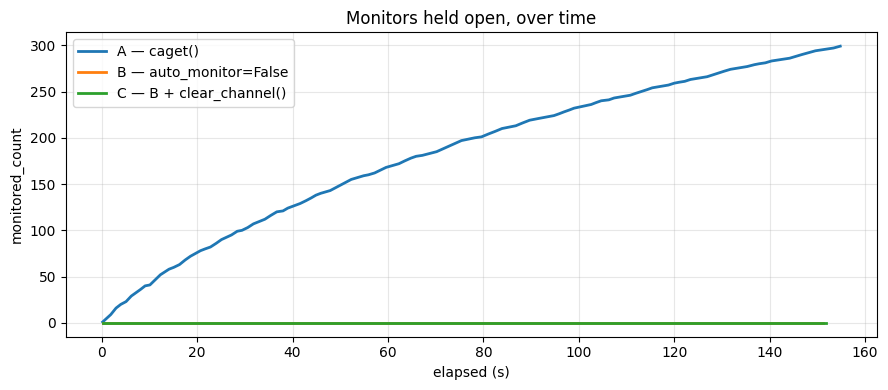

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
for label, df in data.items():
    ax.plot(df["elapsed_s"], df["monitored_count"], label=LABELS[label], color=COLORS[label], lw=2)
ax.set_xlabel("elapsed (s)")
ax.set_ylabel("monitored_count")
ax.set_title("Monitors held open, over time")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()

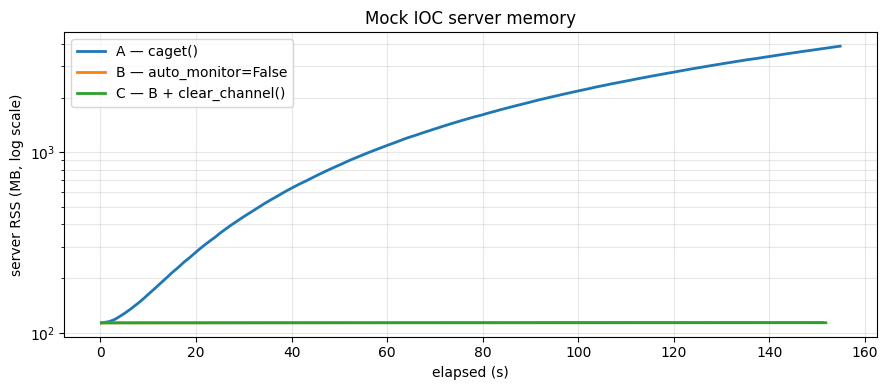

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
for label, df in data.items():
    ax.plot(df["elapsed_s"], df["server_mem_rss_mb"], label=LABELS[label], color=COLORS[label], lw=2)
ax.set_yscale("log")
ax.set_xlabel("elapsed (s)")
ax.set_ylabel("server RSS (MB, log scale)")
ax.set_title("Mock IOC server memory")
ax.legend()
ax.grid(alpha=0.3, which="both")
fig.tight_layout()

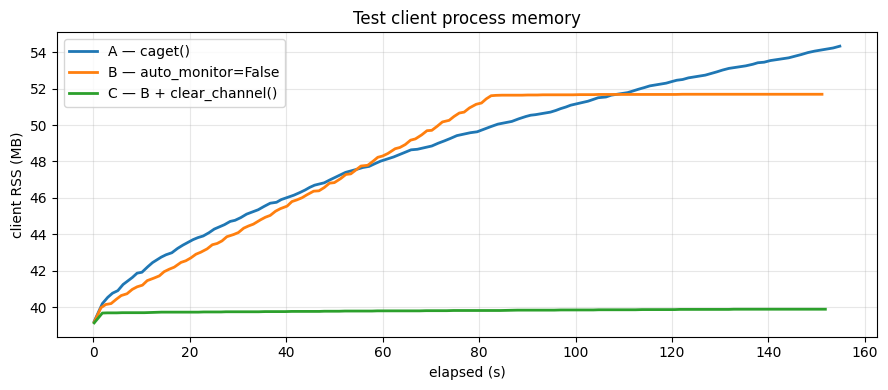

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
for label, df in data.items():
    ax.plot(df["elapsed_s"], df["client_mem_rss_mb"], label=LABELS[label], color=COLORS[label], lw=2)
ax.set_xlabel("elapsed (s)")
ax.set_ylabel("client RSS (MB)")
ax.set_title("Test client process memory")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()

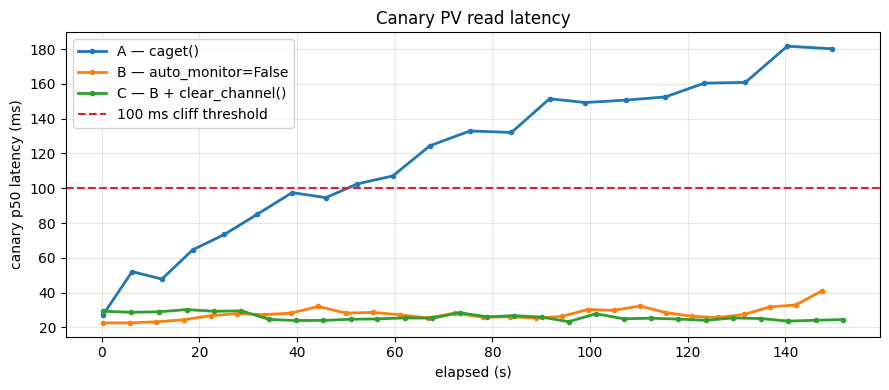

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
for label, df in data.items():
    lat = df.dropna(subset=["latency_p50_ms"])
    ax.plot(lat["elapsed_s"], lat["latency_p50_ms"], label=LABELS[label], color=COLORS[label], lw=2, marker="o", ms=3)
ax.axhline(100, color="tab:red", ls="--", lw=1.5, label="100 ms cliff threshold")
ax.set_xlabel("elapsed (s)")
ax.set_ylabel("canary p50 latency (ms)")
ax.set_title("Canary PV read latency")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()